In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from scipy import stats

In [2]:
rf_data = pd.read_csv("RF_prediction.csv")
rf_data['observationTime'] = pd.to_datetime(rf_data['observationTime'])
rf_data.head()

,observationTime,rf_prediction,actual,ECMWF
0,2024-02-02,4.749,0.5,6.074154
1,2024-02-03,1.195,3.4,2.074088
2,2024-02-04,3.381,6.5,3.847310
3,2024-02-05,3.576,6.2,4.799108
4,2024-02-06,8.456,2.8,8.335825


In [3]:
xgb_data = pd.read_csv("xgboost_pred.csv")
xgb_data['observationTime'] = pd.to_datetime(xgb_data['observationTime'])
xgb_data.head()

,observationTime,actual,xgb_predicted
0,2018-07-12,0.3,1.238406
1,2018-07-13,24.0,22.250040
2,2018-07-14,13.3,15.661434
3,2018-07-15,11.1,10.932304
4,2018-07-16,4.8,2.656915


In [4]:
ssa_lstm_data = pd.read_csv("SSA-LSTM_pred.csv")
ssa_lstm_data['observationTime'] = pd.to_datetime(ssa_lstm_data['observationTime'])
ssa_lstm_data.head()

,Unnamed: 0,observationTime,actual,SSA-LSTM
0,0,2024-08-11,2.1,1.395520
1,1,2024-08-12,0.0,0.567791
2,2,2024-08-13,0.0,0.794638
3,3,2024-08-14,0.0,0.000000
4,4,2024-08-15,0.0,0.348558


In [5]:
data_full = rf_data.merge(xgb_data[['observationTime', 'xgb_predicted']], on='observationTime', how='left')
data_full = data_full.merge(ssa_lstm_data[['observationTime', 'SSA-LSTM']], on='observationTime', how='left')
data_full.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
0,2024-02-02,4.749,0.5,6.074154,5.147978,NaN
1,2024-02-03,1.195,3.4,2.074088,1.390713,NaN
2,2024-02-04,3.381,6.5,3.847310,3.099278,NaN
3,2024-02-05,3.576,6.2,4.799108,4.224149,NaN
4,2024-02-06,8.456,2.8,8.335825,7.595597,NaN


In [6]:
data_full_clean = data_full.dropna() 
data_full_clean.shape

(538, 6)

In [7]:
data_full_clean.head()

,observationTime,rf_prediction,actual,ECMWF,xgb_predicted,SSA-LSTM
191,2024-08-11,1.297,2.1,1.924466,1.329129,1.395520
192,2024-08-12,1.232,0.0,0.910832,0.926465,0.567791
193,2024-08-13,1.286,0.0,1.111319,1.169705,0.794638
194,2024-08-14,0.000,0.0,0.000000,0.146910,0.000000
195,2024-08-15,0.000,0.0,0.000000,0.128554,0.348558


In [8]:
data_full_clean.to_csv('All_predictions.csv', index=False)

In [9]:
split_idx = int(len(data_full_clean) * 0.8)

train = data_full_clean.iloc[:split_idx].copy()
test  = data_full_clean.iloc[split_idx:].copy()

target = 'actual'
drop_cols = ['observationTime', target]

X_train = train.drop(columns=drop_cols)
y_train = train[target]
X_test = test.drop(columns=drop_cols)
y_test = test[target]

In [10]:
X_train.head()

,rf_prediction,ECMWF,xgb_predicted,SSA-LSTM
191,1.297,1.924466,1.329129,1.395520
192,1.232,0.910832,0.926465,0.567791
193,1.286,1.111319,1.169705,0.794638
194,0.000,0.000000,0.146910,0.000000
195,0.000,0.000000,0.128554,0.348558


In [11]:
pradzia = train['observationTime'].min()
pabaiga = train['observationTime'].max()

print(f"Mokymo aibė nuo {pradzia} iki {pabaiga} (dydis: {train.shape})")

Mokymo aibė nuo 2024-08-11 00:00:00 iki 2025-10-14 00:00:00 (dydis: (430, 6))


In [12]:
pradzia = test['observationTime'].min()
pabaiga = test['observationTime'].max()

print(f"Testavimo aibė nuo {pradzia} iki {pabaiga} (dydis: {test.shape})")

Testavimo aibė nuo 2025-10-15 00:00:00 iki 2026-01-30 00:00:00 (dydis: (108, 6))


In [13]:
dt_mdl = DecisionTreeRegressor(random_state=123)
dt_mdl.fit(X_train, y_train)
new_pred_dt_mdl = dt_mdl.predict(X_test)

In [14]:
rf_mdl = RandomForestRegressor(random_state=123)
rf_mdl.fit(X_train, y_train)
new_pred_rf_mdl = rf_mdl.predict(X_test)

In [15]:
def metrics_fun(y_val_true, rf_pred_val):
    print(f'R^2:  {r2_score(y_val_true, rf_pred_val)}')
    print(f'MAE:  {mean_absolute_error(y_val_true, rf_pred_val)}')
    print(f'RMSE: {np.sqrt(mean_squared_error(y_val_true, rf_pred_val))}')
    # print(f'MAPE: {mean_absolute_percentage_error(y_val_true, rf_pred_val)}')
    corr, p_value = stats.spearmanr(y_val_true, rf_pred_val)
    print(f"r_s:  {corr}")

Globalus

In [16]:
metrics_fun(y_test, X_test['ECMWF'])

R^2:  0.6347515712616136
MAE:  1.1437363613788245
RMSE: 2.45239614905015
r_s:  0.7762166354737723


DecisionTreeRegressor

In [17]:
metrics_fun(y_test, new_pred_dt_mdl)

R^2:  0.3358640830536278
MAE:  1.3836916110982693
RMSE: 3.306929461184025
r_s:  0.6896805494927127


RandomForestRegressor

In [18]:
metrics_fun(y_test, new_pred_rf_mdl)

R^2:  0.5010360067501431
MAE:  1.0639879073945653
RMSE: 2.866362086130624
r_s:  0.7944392255389989


In [19]:
rf_default_importances = rf_mdl.feature_importances_
rf_default_importances

array([0.31730577, 0.34814315, 0.15656295, 0.17798813])

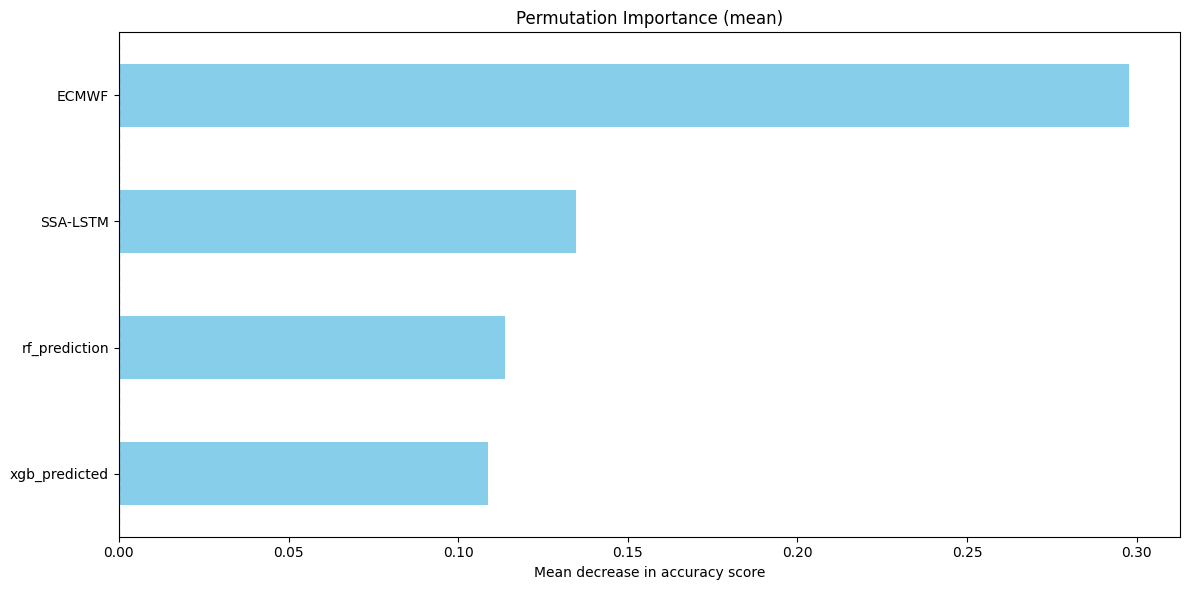

In [20]:
result = permutation_importance(rf_mdl, X_test, y_test, n_repeats=5, random_state=123)
sorted_importances_idx = result.importances_mean.argsort()

importances_df = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test.columns[sorted_importances_idx])

forest_importances = pd.Series(result.importances_mean, index=X_test.columns)
forest_importances = forest_importances[forest_importances > 0]
forest_importances = forest_importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
forest_importances.plot.barh(ax=ax, color='skyblue')
ax.set_title("Permutation Importance (mean)")
ax.set_xlabel("Mean decrease in accuracy score")
ax.axvline(x=0, color="k", linestyle="--")

fig.tight_layout()
plt.show()

In [21]:
# from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# param_grid = {
#     'n_estimators': [50, 100, 150, 200],
#     'max_depth': [None, 4, 6, 8, 10],
#     'max_features': [0.4, 0.7, 0.9, 0.95, 1.0],
#     'min_samples_leaf': [1, 2, 3, 4, 5]
# }

# tscv = TimeSeriesSplit(n_splits=5)
# random_search = GridSearchCV(estimator=RandomForestRegressor(random_state=123), param_grid=param_grid,
#                              cv=tscv, scoring='neg_root_mean_squared_error')
# random_search.fit(X_train, y_train)
# best_model = random_search.best_estimator_
# print(f"Geriausi parametrai: {random_search.best_params_}")

In [22]:
# new_pred = best_model.predict(X_test)
# metrics_fun(y_test, new_pred)